## 1. Install paket

In [1]:
%pip install torch torchvision timm scikit-learn grad-cam seaborn opencv-python tqdm -q

Note: you may need to restart the kernel to use updated packages.


## 2. Imports & Config

In [2]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from timm import create_model
from tqdm import tqdm

# Config
SEED        = 42
DATA_DIR    = "dataset-soto-v2"
NUM_CLASSES = 6
IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 20
LR          = 3e-4
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f"Device: {DEVICE}")


C:\Users\degap\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## 3. Transforms

In [ ]:
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_tf = transforms.Compose([
   transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

## 4. Dataset Info

In [4]:
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"))
val_dataset   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"))
test_dataset  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"))

full_dataset = train_dataset

print(f"  Train  : {len(train_dataset):>6} images")
print(f"  Val    : {len(val_dataset):>6} images")
print(f"  Test   : {len(test_dataset):>6} images")
print(f"\n  Kelas: {train_dataset.classes}")
print(f"\n  Per-class breakdown:")

for i, cls in enumerate(train_dataset.classes):
    tr = sum(1 for _, l in train_dataset.imgs if l == i)
    v  = sum(1 for _, l in val_dataset.imgs   if l == i)
    te = sum(1 for _, l in test_dataset.imgs  if l == i)
    print(f"  {cls:<25} train={tr:>4}  val={v:>3}  test={te:>3}")


  Train  :   3246 images
  Val    :    693 images
  Test   :    693 images

  Kelas: ['coto_makassar', 'soto_bandung', 'soto_betawi', 'soto_lamongan', 'soto_medan', 'soto_padang']

  Per-class breakdown:
  coto_makassar             train= 491  val=105  test=105
  soto_bandung              train= 445  val= 95  test= 95
  soto_betawi               train= 677  val=144  test=144
  soto_lamongan             train= 748  val=160  test=160
  soto_medan                train= 352  val= 75  test= 75
  soto_padang               train= 533  val=114  test=114


## 5. DataLoaders

In [5]:
train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_tf)
val_ds   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"),   transform=eval_tf)
test_ds  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"),  transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")


Train batches : 102
Val   batches : 22
Test  batches : 22


## 6. Model DeiT Tiny

In [6]:
model = create_model("deit_tiny_patch16_224", pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

Total params    : 5,525,574
Trainable params: 5,525,574


## 7. Loss, Optimizer & Scheduler

In [7]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

## 8. Training

In [8]:
import time
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc, best_epoch = 0, 0

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            
            if train: 
                optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            
            if train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)
    scheduler.step()

    history["train_loss"].append(tr_loss); history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc; best_epoch = epoch
        torch.save(model.state_dict(), "Model/Deit_Tiny.pth")
 
    end_time = time.time()
    epoch_mins, epoch_secs = divmod(end_time - start_time, 60)

    print(f"Epoch: {epoch}/{EPOCHS} | Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.2%} | Val Loss: {vl_loss:.4f} | Val Acc: {vl_acc:.2%} | Time: {int(epoch_mins)}m {int(epoch_secs):02d}s")

print(f"Best Val Acc: {best_val_acc:.2%} at epoch {best_epoch}")

Epoch: 1/20 | Train Loss: 1.4137 | Train Acc: 50.15% | Val Loss: 1.0259 | Val Acc: 68.83% | Time: 0m 21s
Epoch: 2/20 | Train Loss: 0.9519 | Train Acc: 74.58% | Val Loss: 0.8664 | Val Acc: 79.37% | Time: 0m 21s
Epoch: 3/20 | Train Loss: 0.8058 | Train Acc: 82.04% | Val Loss: 0.7966 | Val Acc: 82.40% | Time: 0m 21s
Epoch: 4/20 | Train Loss: 0.7262 | Train Acc: 85.89% | Val Loss: 0.7766 | Val Acc: 83.69% | Time: 0m 21s
Epoch: 5/20 | Train Loss: 0.6601 | Train Acc: 89.06% | Val Loss: 0.8089 | Val Acc: 81.24% | Time: 0m 20s
Epoch: 6/20 | Train Loss: 0.6191 | Train Acc: 90.70% | Val Loss: 0.7821 | Val Acc: 84.27% | Time: 0m 21s
Epoch: 7/20 | Train Loss: 0.6010 | Train Acc: 92.11% | Val Loss: 0.7926 | Val Acc: 82.83% | Time: 0m 21s
Epoch: 8/20 | Train Loss: 0.5478 | Train Acc: 94.73% | Val Loss: 0.7418 | Val Acc: 85.71% | Time: 0m 20s
Epoch: 9/20 | Train Loss: 0.5375 | Train Acc: 94.64% | Val Loss: 0.8313 | Val Acc: 82.40% | Time: 0m 20s
Epoch: 10/20 | Train Loss: 0.5035 | Train Acc: 96.58% |

## 9. Training Curve

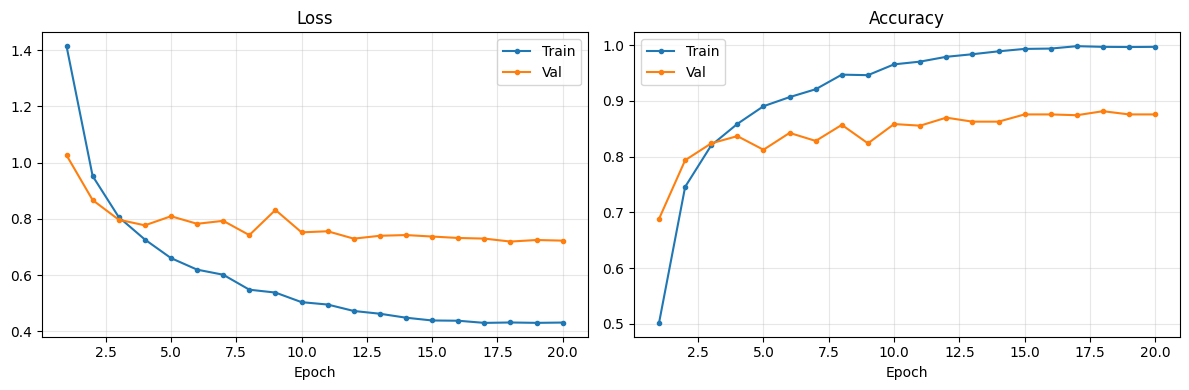

In [9]:
epochs_range = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, history["train_loss"], label="Train", marker="o", ms=3)
ax1.plot(epochs_range, history["val_loss"],   label="Val",   marker="o", ms=3)
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_range, history["train_acc"],  label="Train", marker="o", ms=3)
ax2.plot(epochs_range, history["val_acc"],    label="Val",   marker="o", ms=3)
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Dokumentasi/training_curve(Deit_Tiny).png", dpi=120)
plt.show()

## 10. Evaluation test Set

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.load_state_dict(torch.load("Model/Deit_Tiny.pth", map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        preds = model(imgs.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

print(classification_report(all_labels, all_preds, target_names=full_dataset.classes))

C:\Users\degap\AppData\Local\Temp\ipykernel_3836\3722357806.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("Model/Deit_Tiny.pth", map_l

               precision    recall  f1-score   support

coto_makassar       0.91      0.88      0.89       105
 soto_bandung       0.95      0.87      0.91        95
  soto_betawi       0.85      0.92      0.88       144
soto_lamongan       0.85      0.93      0.89       160
   soto_medan       0.85      0.68      0.76        75
  soto_padang       0.89      0.89      0.89       114

     accuracy                           0.88       693
    macro avg       0.88      0.86      0.87       693
 weighted avg       0.88      0.88      0.88       693



## 11. Confusion Matrix

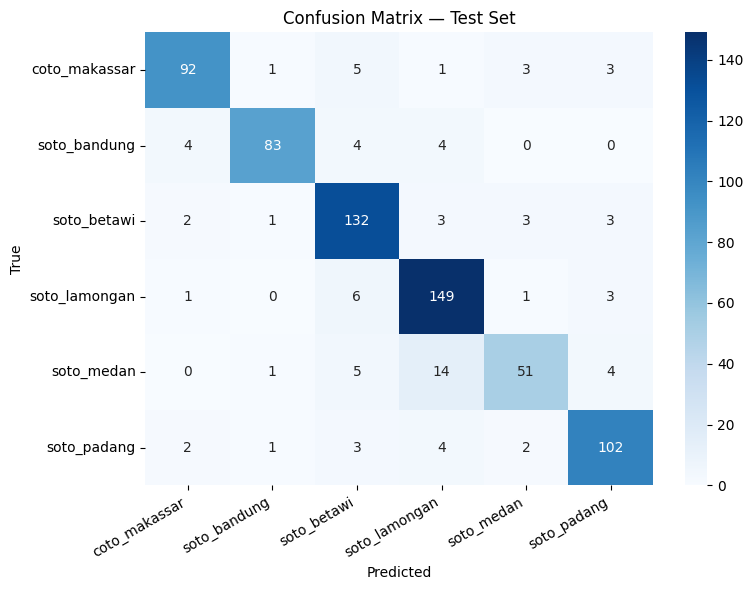

In [11]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)
plt.title("Confusion Matrix — Test Set")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("Dokumentasi/confusion_matrix(Deit_Tiny).png", dpi=120)
plt.show()

## 12. Grad-CAM Visualization

In [12]:
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Reshape transform khusus untuk Vision Transformer (DeiT)
def reshape_transform(tensor, height=14, width=14):
    # Buang CLS token (index 0), ambil patch tokens saja
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    # (B, H, W, C) → (B, C, H, W)
    result = result.transpose(2, 3).transpose(1, 2)
    return result

# Target layer — norm1 di block terakhir DeiT
target_layers = [model.blocks[-1].norm1]
cam = GradCAMPlusPlus(model=model, target_layers=target_layers,
                      reshape_transform=reshape_transform)

def denorm(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = tensor.cpu().numpy().transpose(1, 2, 0)
    img  = (img * std) + mean
    return np.clip(img, 0, 1)

def get_attribution(img_path, actual_class_str=None):
    from PIL import Image

    pil_img = Image.open(img_path).convert('RGB')
    img_t   = eval_tf(pil_img)
    input_t = img_t.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(input_t)
        pred_prob, pred_class = torch.max(logits.softmax(1), 1)
        pred_class = pred_class.item()
        pred_prob  = pred_prob.item()

    pred_class_str = full_dataset.classes[pred_class]
    actual_str = f"Actual: {actual_class_str}" if actual_class_str else ""

    rgb_img = denorm(img_t).astype(np.float32)
    grayscale_cam = cam(input_tensor=input_t,
                        targets=[ClassifierOutputTarget(pred_class)])[0]
    cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"{actual_str}\nPredicted: {pred_class_str} ({pred_prob*100:.2f}%)",
                 fontsize=12, fontweight="bold")

    axes[0].imshow(rgb_img)
    axes[0].set_title("Input Image", fontsize=11)
    axes[0].axis("off")

    axes[1].imshow(grayscale_cam, cmap='hot')
    axes[1].set_title("Heatmap", fontsize=11)
    axes[1].axis("off")

    axes[2].imshow(cam_image)
    axes[2].set_title("Class Activation Map", fontsize=11)
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    return pred_class_str, pred_prob

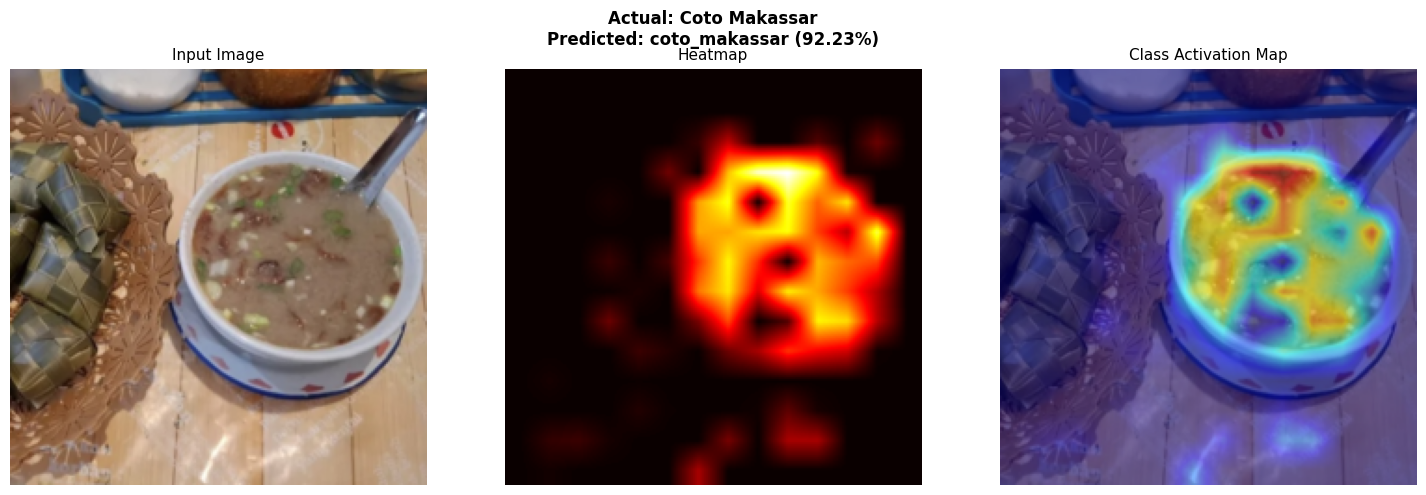

In [13]:
pred = get_attribution('dataset-soto-v2/test/coto_makassar/makassar-0699.jpg', actual_class_str='Coto Makassar')

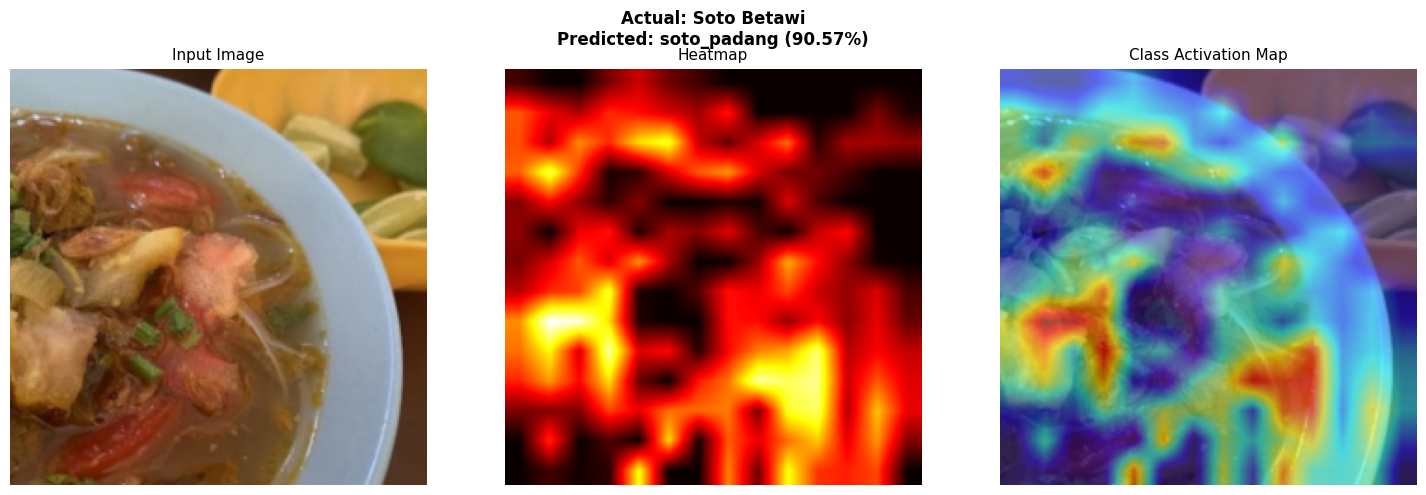

In [14]:
pred = get_attribution('dataset-soto-v2/test/soto_betawi/betawi-0831.jpg', actual_class_str='Soto Betawi')